## import libraries

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go


## read of data

In [126]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vijayaadithyanvg/car-price-predictionused-cars")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-price-predictionused-cars' dataset.
Path to dataset files: /kaggle/input/car-price-predictionused-cars


In [127]:
path

'/kaggle/input/car-price-predictionused-cars'

In [128]:
df = pd.read_csv(path+"/car data.csv")

In [129]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


## processing of data

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [131]:
df['Car_Name'].nunique()

98

In [132]:
import datetime
dtime=datetime.datetime.now()



In [133]:
df["age"] = dtime.year - df["Year"]

In [134]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,9


In [135]:
df.isnull().sum().sort_values(ascending=False)

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0
age,0


In [136]:
df.duplicated().sum()

np.int64(2)

In [137]:
df.drop_duplicates(inplace=True)

In [138]:
df.duplicated().sum()

np.int64(0)

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Selling_type   299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
 9   age            299 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 25.7+ KB


In [140]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,age
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478,12.384615
std,2.896868,4.984240,8.566332,39015.170352,0.248720,2.896868
min,2003.000000,0.100000,0.320000,500.000000,0.000000,8.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000,10.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000,12.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000,14.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000,23.000000


In [141]:
for col in df.columns:
  print(col,":",df[col].nunique())

Car_Name : 98
Year : 16
Selling_Price : 156
Present_Price : 148
Driven_kms : 206
Fuel_Type : 3
Selling_type : 2
Transmission : 2
Owner : 3
age : 16


## visualuzation and discover data

In [142]:
px.box(data_frame=df,x="Selling_Price")

In [143]:
fig = px.scatter(
    df,
    x="Selling_Price",
    y="Present_Price",
    color="Fuel_Type",
    trendline="ols",
    trendline_color_override="red"

)
fig.show()

In [144]:
fig = px.scatter(
    df,
    x="Selling_Price",
    y="Present_Price",
    color="Transmission",
    trendline="ols",
    trendline_color_override="green"
)
fig.show()

In [145]:
fig = px.scatter_3d(
    df,
    x="Selling_Price",
    y="Present_Price",
    z="age",
    color="Fuel_Type",
    opacity=0.7
)
fig.show()

In [146]:
px.box(data_frame=df,x='Present_Price')

## remove outliers

In [147]:
df = df[df['Present_Price'] < 40]

In [148]:
px.box(data_frame=df,x='Present_Price')

In [149]:
px.box(data_frame=df,x="Selling_Price")

In [150]:
df = df[df['Selling_Price'] < 20]

In [151]:
px.box(data_frame=df,x="Selling_Price")

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 293 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       293 non-null    object 
 1   Year           293 non-null    int64  
 2   Selling_Price  293 non-null    float64
 3   Present_Price  293 non-null    float64
 4   Driven_kms     293 non-null    int64  
 5   Fuel_Type      293 non-null    object 
 6   Selling_type   293 non-null    object 
 7   Transmission   293 non-null    object 
 8   Owner          293 non-null    int64  
 9   age            293 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 25.2+ KB


In [153]:
fig = px.pie(
    df,
    names="Fuel_Type",
    title="Fuel Type Distribution"
)

fig.show()

<Axes: xlabel='Transmission', ylabel='Selling_Price'>

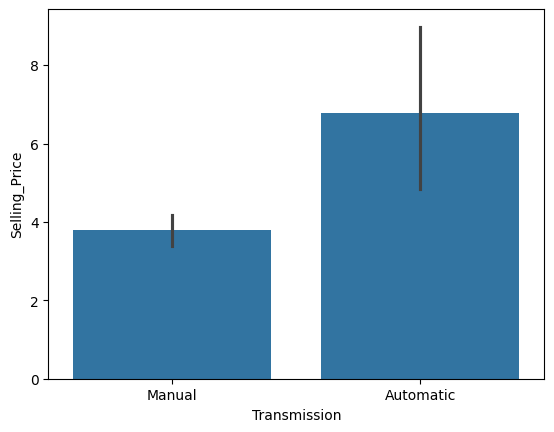

In [154]:
sns.barplot(data=df,x='Transmission',y="Selling_Price")

<Axes: xlabel='Fuel_Type', ylabel='Selling_Price'>

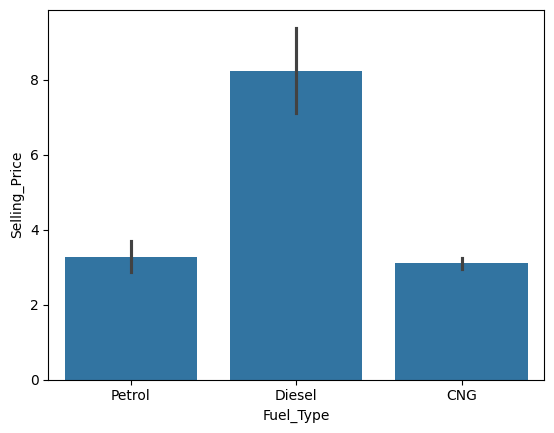

In [155]:
sns.barplot(data=df,x="Fuel_Type",y="Selling_Price")

<Axes: xlabel='Year', ylabel='Selling_Price'>

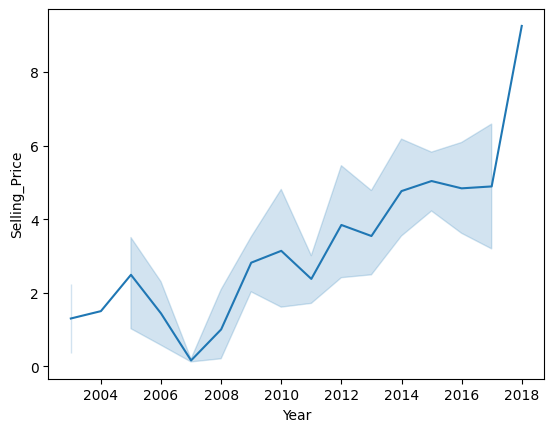

In [156]:
sns.lineplot(data=df,x="Year",y="Selling_Price")

<Axes: xlabel='Present_Price', ylabel='Count'>

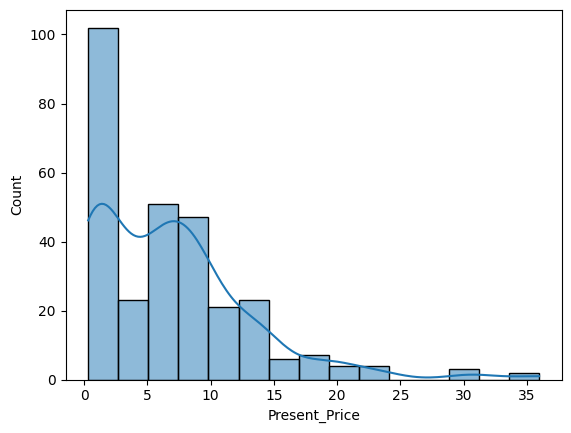

In [157]:
sns.histplot(data=df,x="Present_Price",kde=True)

<Axes: xlabel='Driven_kms', ylabel='Count'>

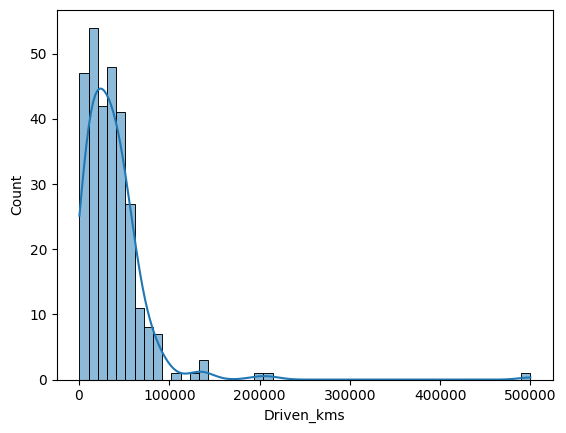

In [158]:
sns.histplot(data=df,x="Driven_kms",kde=True)

In [159]:
px.box(data_frame=df,x="Driven_kms")

In [160]:
df = df[df['Driven_kms']<200000]

In [161]:
px.box(data_frame=df,x="Driven_kms")

In [162]:
px.violin(data_frame=df,x="Present_Price")

<Axes: xlabel='Present_Price', ylabel='Selling_Price'>

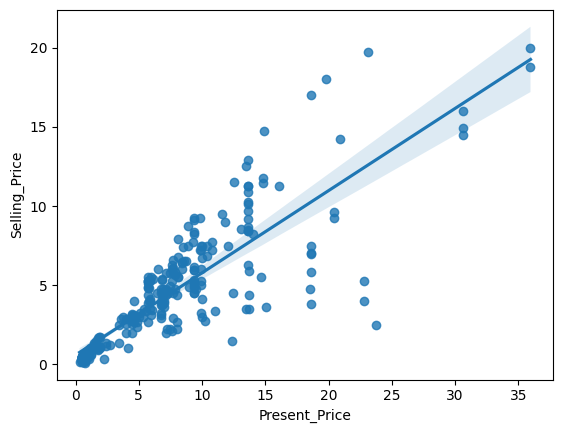

In [163]:
sns.regplot(data=df,x="Present_Price",y="Selling_Price")

<Axes: xlabel='age', ylabel='Selling_Price'>

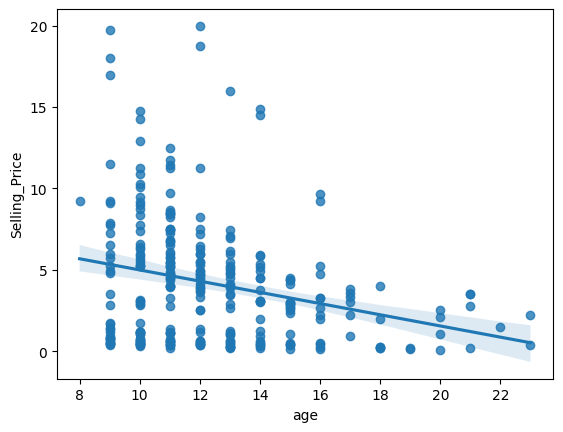

In [164]:
sns.regplot(data=df,x="age",y="Selling_Price")

<Axes: xlabel='age', ylabel='Present_Price'>

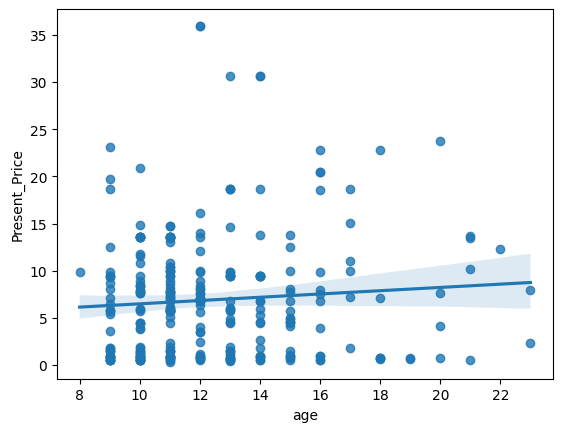

In [165]:
sns.regplot(data=df,x="age",y="Present_Price")

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 291 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       291 non-null    object 
 1   Year           291 non-null    int64  
 2   Selling_Price  291 non-null    float64
 3   Present_Price  291 non-null    float64
 4   Driven_kms     291 non-null    int64  
 5   Fuel_Type      291 non-null    object 
 6   Selling_type   291 non-null    object 
 7   Transmission   291 non-null    object 
 8   Owner          291 non-null    int64  
 9   age            291 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 25.0+ KB


<Axes: >

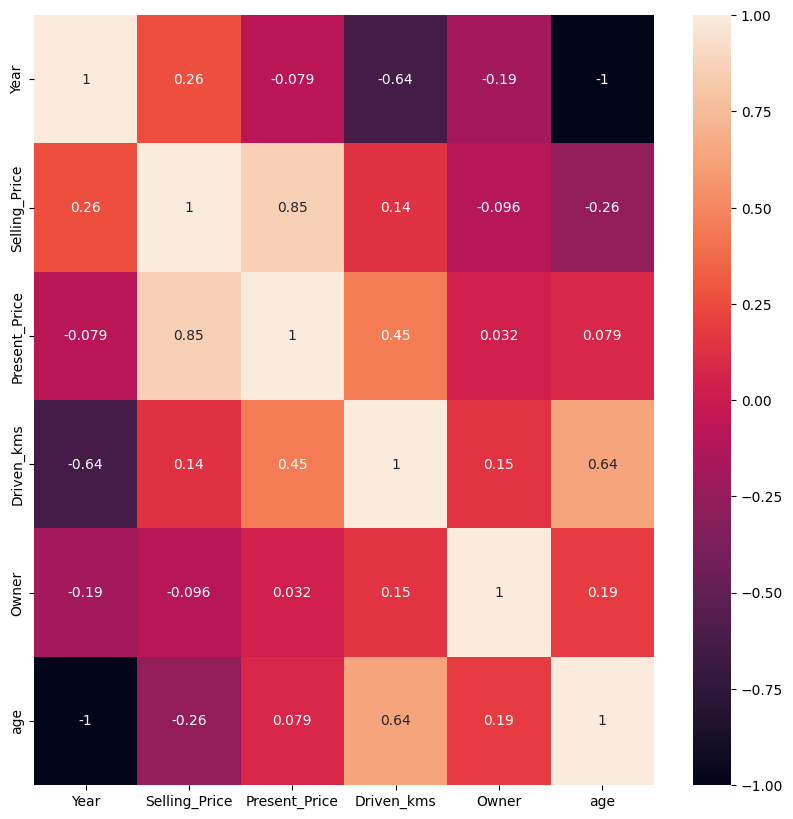

In [167]:
plt.figure(figsize=(10,10))
df_corr = df.select_dtypes(exclude=['object'])
sns.heatmap(df_corr.corr(),annot=True)

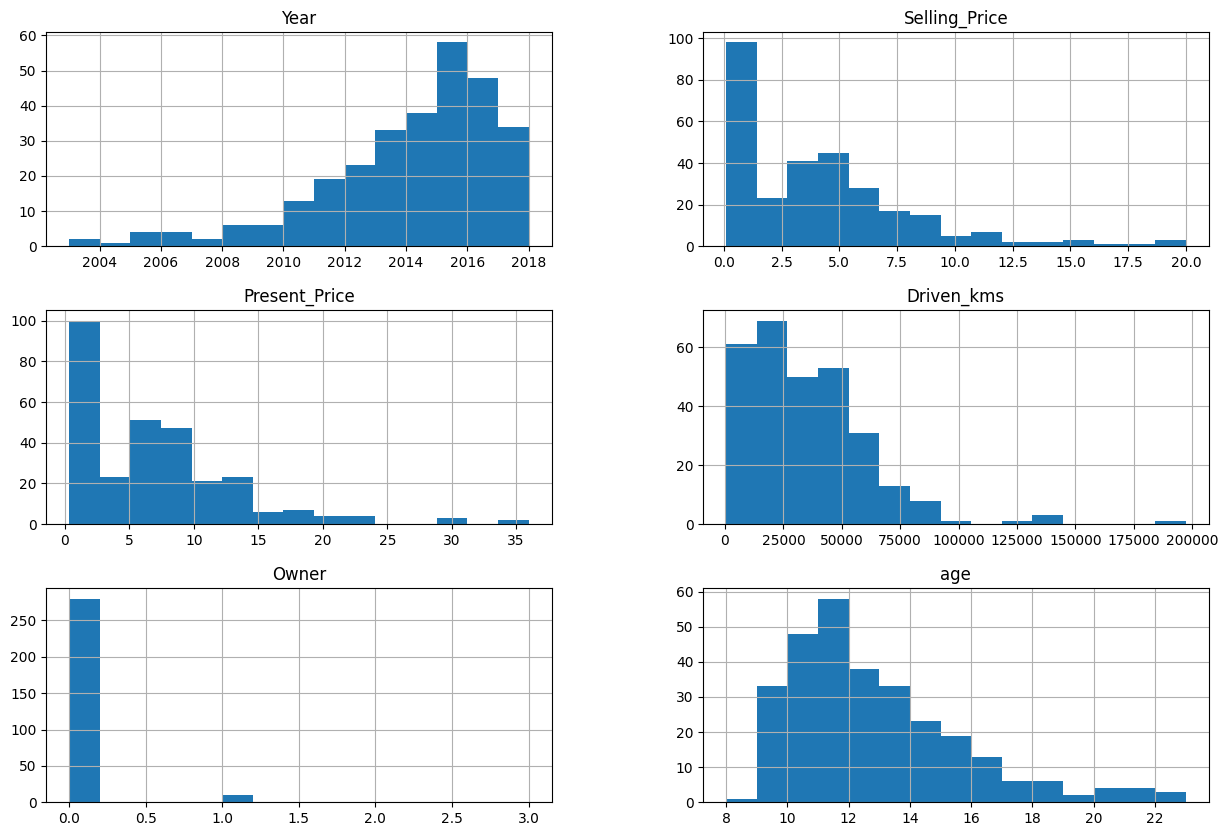

In [168]:
df.hist(bins=15,figsize=(15,10))
plt.show()

In [169]:
top10car=df.sort_values(by='Selling_Price',ascending=False).head(10)

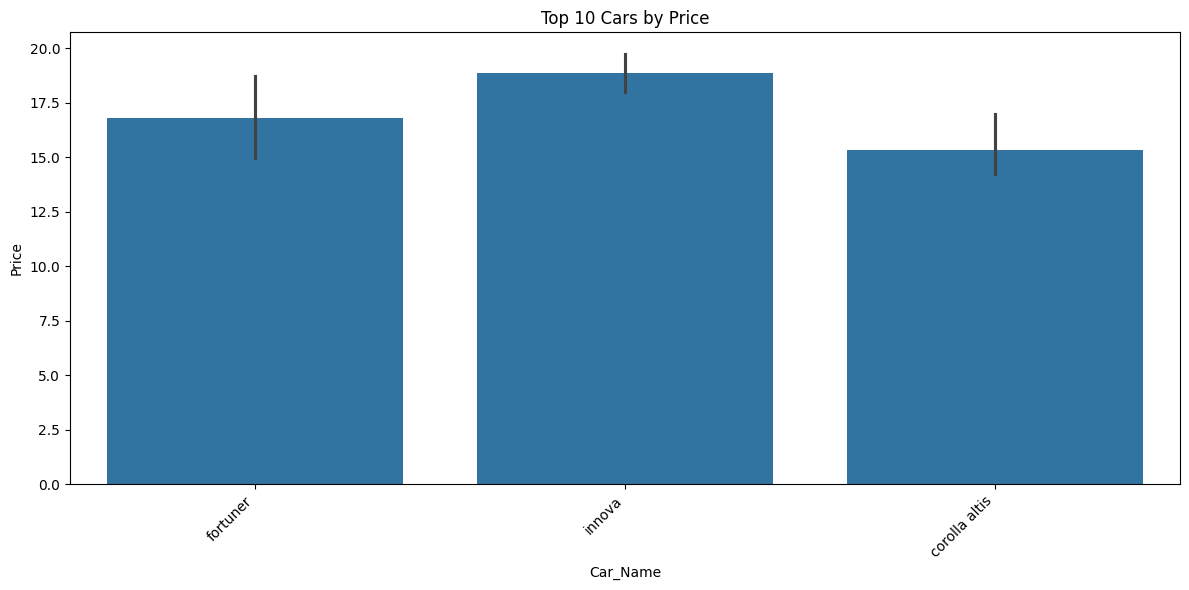

In [170]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top10car, x='Car_Name', y='Selling_Price')
plt.title('Top 10 Cars by Price')
plt.xlabel('Car_Name')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [171]:
df.drop('Year',axis=1,inplace=True)

In [172]:
df.reset_index(drop=True,inplace=True)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       291 non-null    object 
 1   Selling_Price  291 non-null    float64
 2   Present_Price  291 non-null    float64
 3   Driven_kms     291 non-null    int64  
 4   Fuel_Type      291 non-null    object 
 5   Selling_type   291 non-null    object 
 6   Transmission   291 non-null    object 
 7   Owner          291 non-null    int64  
 8   age            291 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 20.6+ KB


## encoding

In [174]:
for col in df.columns:
  print(col,":",df[col].nunique())

Car_Name : 97
Selling_Price : 149
Present_Price : 145
Driven_kms : 204
Fuel_Type : 3
Selling_type : 2
Transmission : 2
Owner : 3
age : 16


## label = ['Owner',]
## one hot =['Fuel_Type'.'Transmission','Selling_type']
## target encoding =['car_name']

In [175]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
cols = ['Owner']
for col in cols:
  df[col]=lb.fit_transform(df[col])

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       291 non-null    object 
 1   Selling_Price  291 non-null    float64
 2   Present_Price  291 non-null    float64
 3   Driven_kms     291 non-null    int64  
 4   Fuel_Type      291 non-null    object 
 5   Selling_type   291 non-null    object 
 6   Transmission   291 non-null    object 
 7   Owner          291 non-null    int64  
 8   age            291 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 20.6+ KB


In [177]:
from kagglehub import handle
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform='pandas')
ohe_transform=ohe.fit_transform(df[['Fuel_Type','Transmission','Selling_type']])
df = pd.concat([df,ohe_transform],axis=1)
df.drop(['Fuel_Type','Transmission','Selling_type'],axis=1,inplace=True)


In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Car_Name                 291 non-null    object 
 1   Selling_Price            291 non-null    float64
 2   Present_Price            291 non-null    float64
 3   Driven_kms               291 non-null    int64  
 4   Owner                    291 non-null    int64  
 5   age                      291 non-null    int64  
 6   Fuel_Type_CNG            291 non-null    float64
 7   Fuel_Type_Diesel         291 non-null    float64
 8   Fuel_Type_Petrol         291 non-null    float64
 9   Transmission_Automatic   291 non-null    float64
 10  Transmission_Manual      291 non-null    float64
 11  Selling_type_Dealer      291 non-null    float64
 12  Selling_type_Individual  291 non-null    float64
dtypes: float64(9), int64(3), object(1)
memory usage: 29.7+ KB


In [179]:
pip install category_encoders

In [180]:
from category_encoders import TargetEncoder
te = TargetEncoder(cols=['Car_Name'])
df['Car_Name_Encoded'] = te.fit_transform(df['Car_Name'], df['Selling_Price'])
df.drop('Car_Name', axis=1, inplace=True)

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Selling_Price            291 non-null    float64
 1   Present_Price            291 non-null    float64
 2   Driven_kms               291 non-null    int64  
 3   Owner                    291 non-null    int64  
 4   age                      291 non-null    int64  
 5   Fuel_Type_CNG            291 non-null    float64
 6   Fuel_Type_Diesel         291 non-null    float64
 7   Fuel_Type_Petrol         291 non-null    float64
 8   Transmission_Automatic   291 non-null    float64
 9   Transmission_Manual      291 non-null    float64
 10  Selling_type_Dealer      291 non-null    float64
 11  Selling_type_Individual  291 non-null    float64
 12  Car_Name_Encoded         291 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 29.7 KB


## split data

In [182]:
from sklearn.model_selection import train_test_split

In [183]:
x=df.drop('Selling_Price',axis=1)
y=df['Selling_Price']

In [184]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## scaling

In [185]:
from sklearn.preprocessing import StandardScaler

In [186]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

## build model and predict

In [187]:
pip install xgboost

In [188]:
pip install lightgbm

In [189]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


In [190]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [192]:
from math import gamma
models={
    "LinearRegression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "ElasticNet":ElasticNet(),
    "knn":KNeighborsRegressor(n_neighbors=20,metric="manhattan"),
    "DecisionTreeRegressor":DecisionTreeRegressor(max_depth=15),
    "RandomForestRegressor":RandomForestRegressor(n_estimators=50,max_depth=15),
    "SVR":SVR(C=60,gamma=1),
   "GradientBoostingRegressor":GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,max_depth=20),
    "BaggingRegressor":BaggingRegressor(n_estimators=20),
    "AdaBoostRegressor":AdaBoostRegressor(n_estimators=50,learning_rate=0.1),
    "VotingRegressor":VotingRegressor(estimators=[("lr",LinearRegression()),("knn",KNeighborsRegressor())]),
    "StackingRegressor":StackingRegressor(estimators=[("lr",LinearRegression()),("knn",KNeighborsRegressor()),("dt",DecisionTreeRegressor()),("ba",BaggingRegressor()),("et",ExtraTreeRegressor())]),
    "ExtraTreeRegressor":ExtraTreeRegressor(),
    "HistGradientBoostingRegressor":HistGradientBoostingRegressor(max_iter=100,max_depth=3),
    "ExtraTreesRegressor":ExtraTreesRegressor(n_estimators=60,max_depth=35),
    "XGBRegressor":XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=50)
}

In [193]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
accuracy=[]
for model_name , model in models.items():
    model.fit(x_train,y_train)
    y_pre_train=model.predict(x_train)
    y_pre_test=model.predict(x_test)
    accuracy.append({
        "model":model_name,
        "MSE_train":mean_squared_error(y_train,y_pre_train),
        "MSE_test":mean_squared_error(y_test,y_pre_test),
        "MAE_train":mean_absolute_error(y_train,y_pre_train),
        "MAE_test":mean_absolute_error(y_test,y_pre_test),
        "R2_train":r2_score(y_train,y_pre_train),
        "R2_test":r2_score(y_test,y_pre_test)
    })

In [194]:
pd.DataFrame(accuracy).sort_values(by="R2_test",ascending=False)

,model,MSE_train,MSE_test,MAE_train,MAE_test,R2_train,R2_test
15,ExtraTreesRegressor,1.339787e-29,0.526110,1.984045e-15,0.435517,1.000000,0.965080
9,BaggingRegressor,1.130732e-01,0.575546,1.966466e-01,0.512339,0.992276,0.961798
13,ExtraTreeRegressor,3.984683e-35,0.578083,7.178166e-19,0.492034,1.000000,0.961630
6,RandomForestRegressor,1.304119e-01,0.586653,1.912315e-01,0.491260,0.991092,0.961061
8,GradientBoostingRegressor,1.032822e-08,0.692223,7.692926e-05,0.550817,1.000000,0.954054
12,StackingRegressor,1.405770e-01,0.721114,2.578959e-01,0.593595,0.990397,0.952136
16,XGBRegressor,3.127981e-05,0.721873,2.371577e-03,0.554770,0.999998,0.952086
11,VotingRegressor,1.157357e+00,0.738740,6.895247e-01,0.633912,0.920942,0.950966
10,AdaBoostRegressor,6.308392e-01,0.804522,5.293263e-01,0.650381,0.956908,0.946600
5,DecisionTreeRegressor,3.984683e-35,0.827749,7.178166e-19,0.577627,1.000000,0.945058


## save models and encoding and scaling

In [196]:
import joblib

In [197]:
joblib.dump(model, 'extra_trees_model.pkl')

['extra_trees_model.pkl']

In [198]:
joblib.dump(te, 'target_encoder_car_name.pkl')

['target_encoder_car_name.pkl']

In [199]:
joblib.dump(ohe, 'onehot_encoder.pkl')

['onehot_encoder.pkl']

In [201]:
joblib.dump(lb, 'label_encoder_owner.pkl')

['label_encoder_owner.pkl']

In [202]:
joblib.dump(scaler, 'standard_scaler.pkl')

['standard_scaler.pkl']